# Optimisation de la Gestion des Déchets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msn
from tabulate import tabulate

In [2]:
data = pd.read_csv("waste_dataset_for_analysis.csv")
data.head(7)

,Area,Population_Density,Household_Size,Waste_Generation,Collection_Frequency,Recycling_Rate,Collection_Point_Location,Road_Network_Score,Disposal_Site_Distance,Pollution_Level,Top 1 Waste_Type,Top 2 Waste_Type,Top 3 Waste_Type
0,Quartier_1,8270.0,6,3.39,6,0.35,53,0.98,2.13,0.72,Paper,Plastic,Glass
1,Quartier_2,1860.0,4,2.31,2,0.74,40,0.49,17.95,0.31,Paper,Metal,Glass
2,Quartier_3,6390.0,5,1.20,2,0.69,53,0.72,4.62,0.47,Glass,Organic,Paper
3,Quartier_4,6191.0,6,0.56,3,0.85,74,0.82,2.38,0.20,Glass,Metal,Organic
4,Quartier_5,6734.0,5,2.11,1,0.62,52,0.72,2.46,0.48,Organic,Plastic,Glass
5,Quartier_6,7265.0,5,3.35,5,0.17,81,0.54,4.60,0.14,Organic,Glass,Plastic
6,Quartier_7,NaN,4,2.85,4,NaN,3,0.48,13.81,0.24,Metal,Paper,Plastic


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Area                       154 non-null    object 
 1   Population_Density         143 non-null    float64
 2   Household_Size             154 non-null    int64  
 3   Waste_Generation           154 non-null    float64
 4   Collection_Frequency       154 non-null    int64  
 5   Recycling_Rate             143 non-null    float64
 6   Collection_Point_Location  154 non-null    int64  
 7   Road_Network_Score         154 non-null    float64
 8   Disposal_Site_Distance     154 non-null    float64
 9   Pollution_Level            154 non-null    float64
 10  Top 1 Waste_Type           154 non-null    object 
 11  Top 2 Waste_Type           154 non-null    object 
 12  Top 3 Waste_Type           154 non-null    object 
dtypes: float64(6), int64(3), object(4)
memory usage: 1

In [4]:
data.describe()

,Population_Density,Household_Size,Waste_Generation,Collection_Frequency,Recycling_Rate,Collection_Point_Location,Road_Network_Score,Disposal_Site_Distance,Pollution_Level
count,143.000000,154.000000,154.000000,154.000000,143.000000,154.000000,154.000000,154.000000,154.000000
mean,5856.916084,4.785714,4.519585,3.688312,0.546224,55.402597,0.519935,14.634561,0.365065
std,2639.684727,1.664565,10.116414,1.802393,0.259101,27.926261,0.269860,40.766003,0.262970
min,1064.000000,2.000000,0.540000,1.000000,0.010000,1.000000,0.000000,0.260000,0.000000
25%,3590.000000,3.000000,1.527500,2.000000,0.335000,31.500000,0.295000,2.612500,0.150000
50%,6390.000000,5.000000,2.710000,4.000000,0.570000,55.000000,0.550000,4.535000,0.335000
75%,8153.500000,6.000000,4.037500,5.000000,0.740000,78.750000,0.740000,12.467500,0.500000
max,9996.000000,7.000000,77.935890,6.000000,1.000000,100.000000,1.000000,319.546830,1.000000


# Prétraitement des données

In [5]:
# Verifions les doublons
data.duplicated().sum()

11

In [6]:
# Supprimons les doublons
data = data.drop_duplicates()

In [7]:
# Valeurs manquantes
data.isna().sum()

Area                          0
Population_Density           11
Household_Size                0
Waste_Generation              0
Collection_Frequency          0
Recycling_Rate               11
Collection_Point_Location     0
Road_Network_Score            0
Disposal_Site_Distance        0
Pollution_Level               0
Top 1 Waste_Type              0
Top 2 Waste_Type              0
Top 3 Waste_Type              0
dtype: int64

<Axes: >

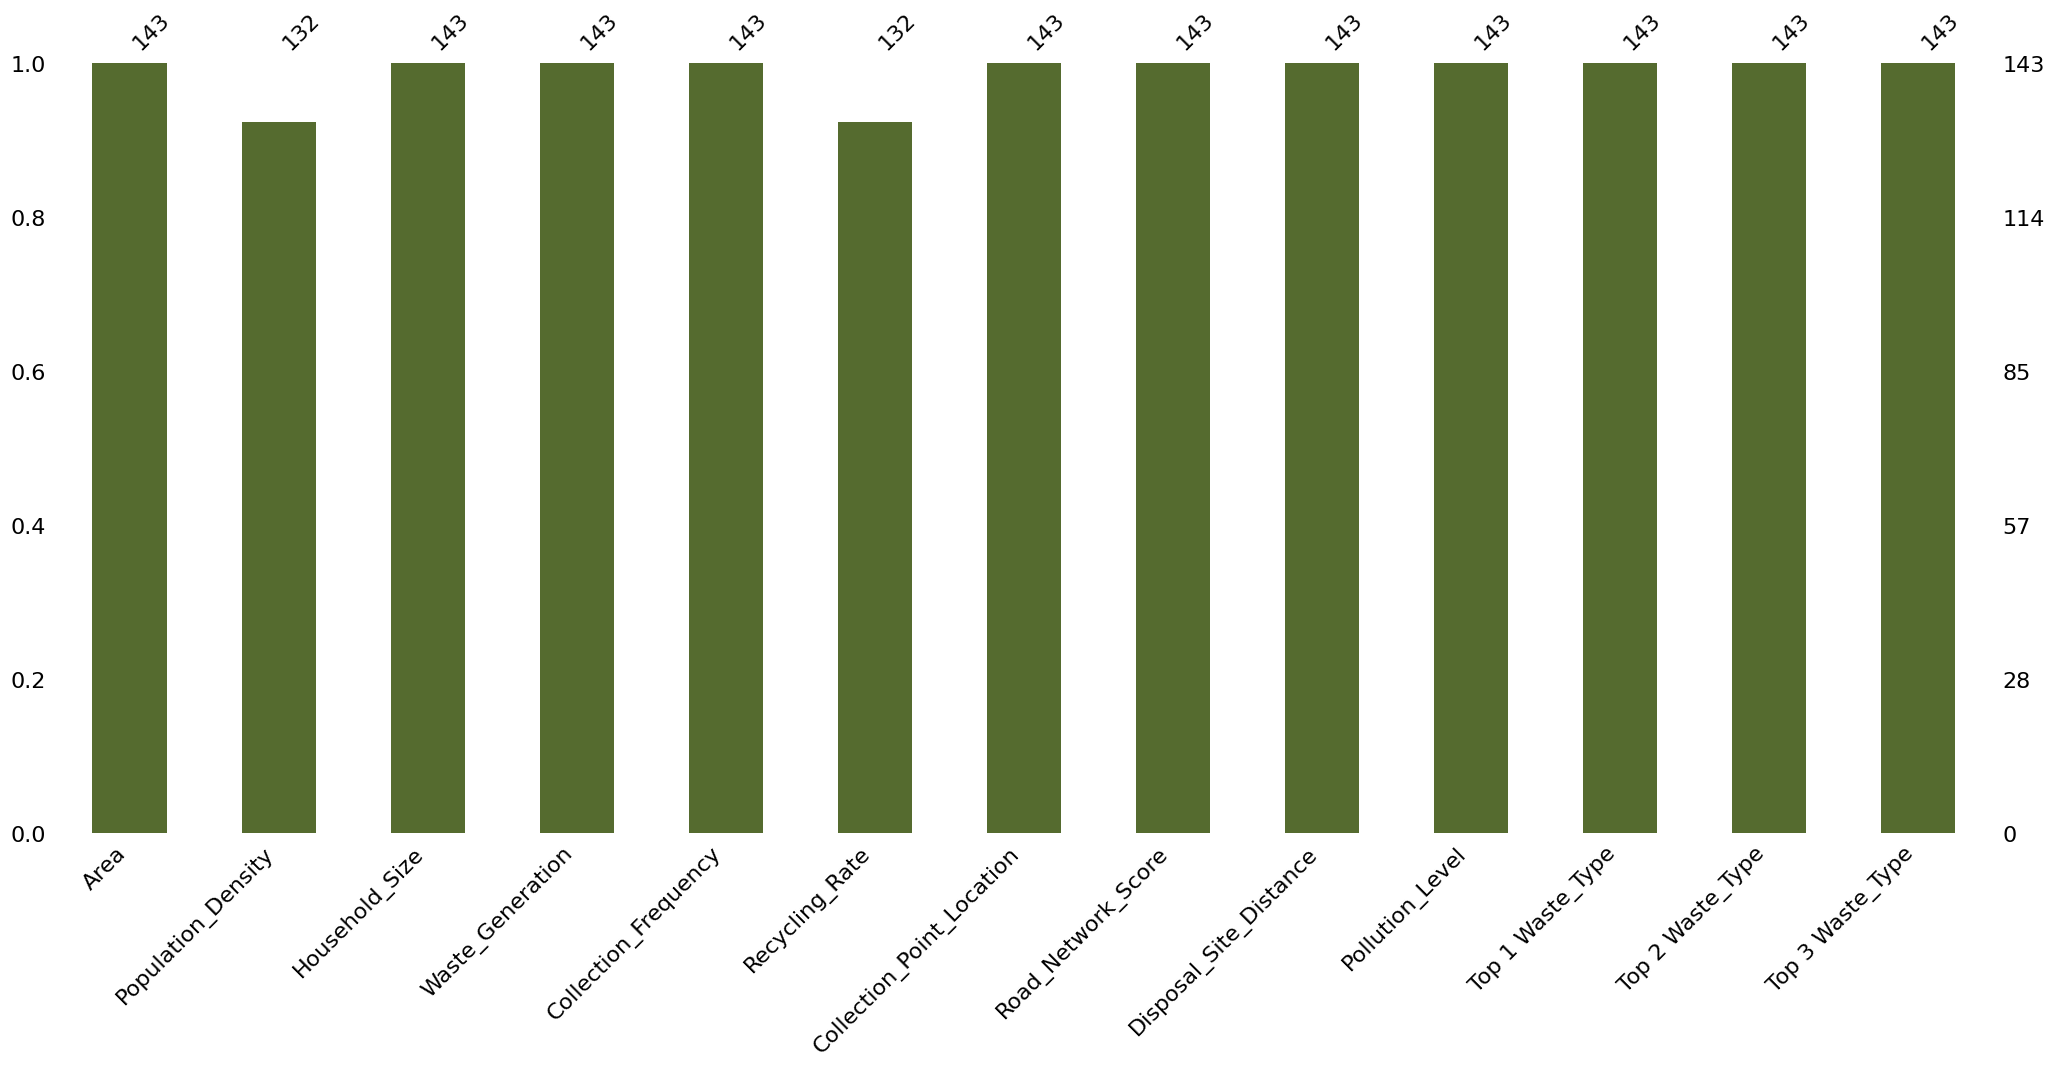

In [8]:
# Visualisation Valeurs manquantes
msn.bar(data, color='darkolivegreen')

In [9]:
# Suppression des valeurs manquantes
data=data.dropna()

# Visualisation des données

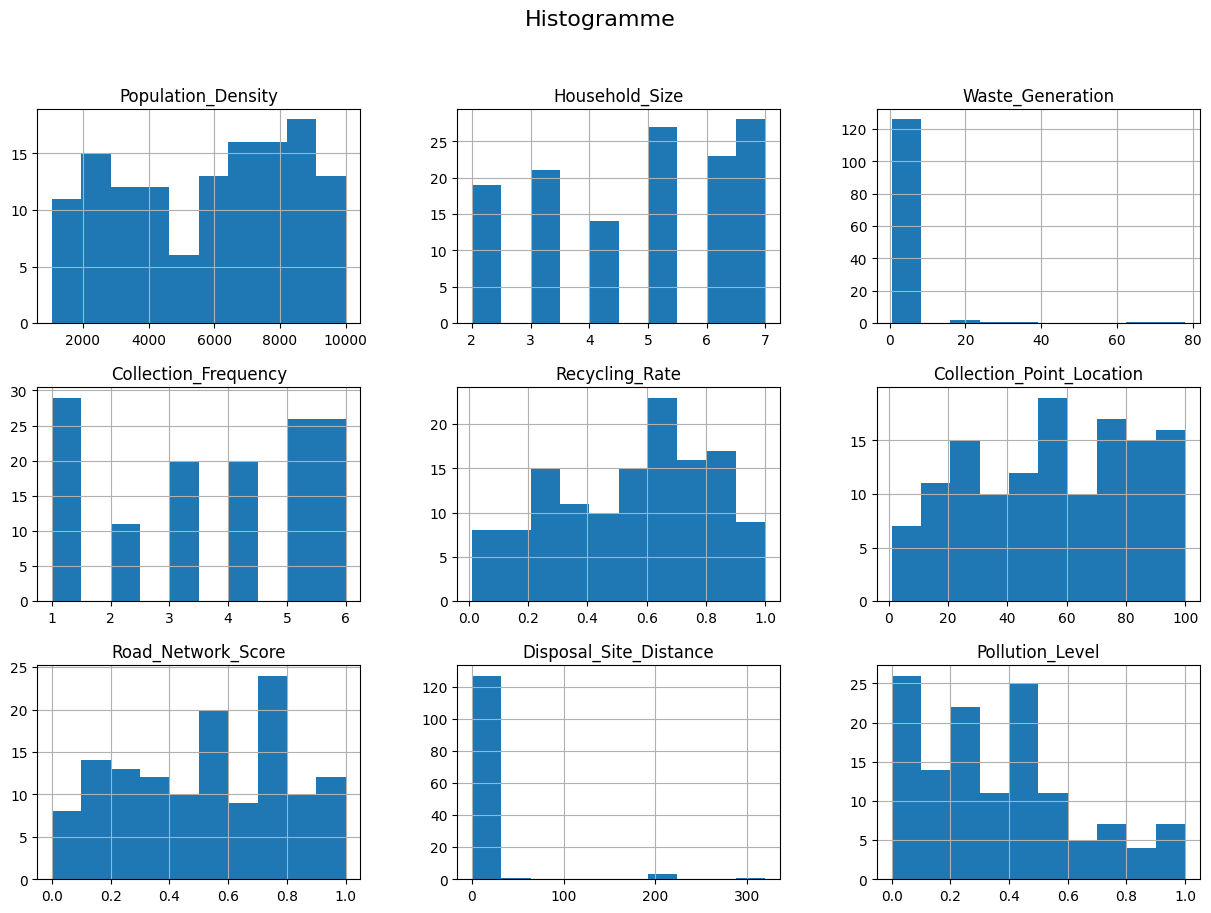

In [10]:
# Histogramme
data.hist(figsize=(15, 10))
plt.suptitle("Histogramme", fontsize=16)
plt.show()

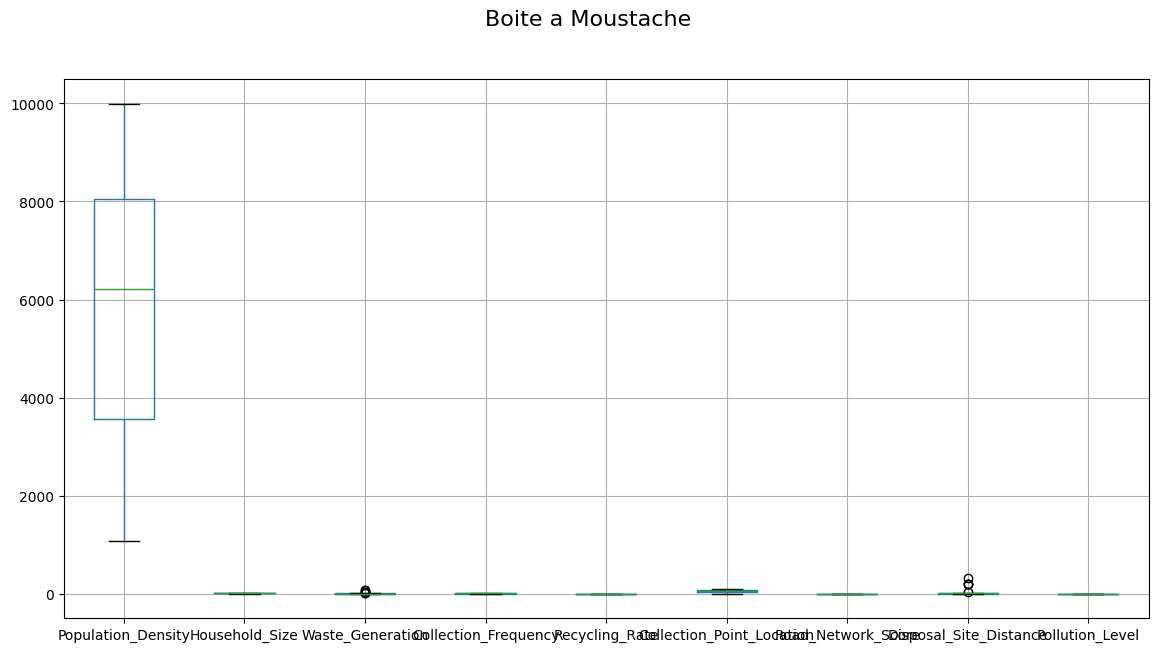

In [11]:

data.boxplot(column=['Population_Density', 'Household_Size', 'Waste_Generation','Collection_Frequency', 'Recycling_Rate','Collection_Point_Location','Road_Network_Score', 'Disposal_Site_Distance', 'Pollution_Level'], figsize=(14, 7))
plt.suptitle('Boite a Moustache', fontsize=16)
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_2480\2607942656.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data2[colonne], color="orange")
C:\Users\pc\AppData\Local\Temp\ipykernel_2480\2607942656.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data2[colonne], color="orange")
C:\Users\pc\Ap

ValueError: num must be an integer with 1 <= num <= 8, not 9

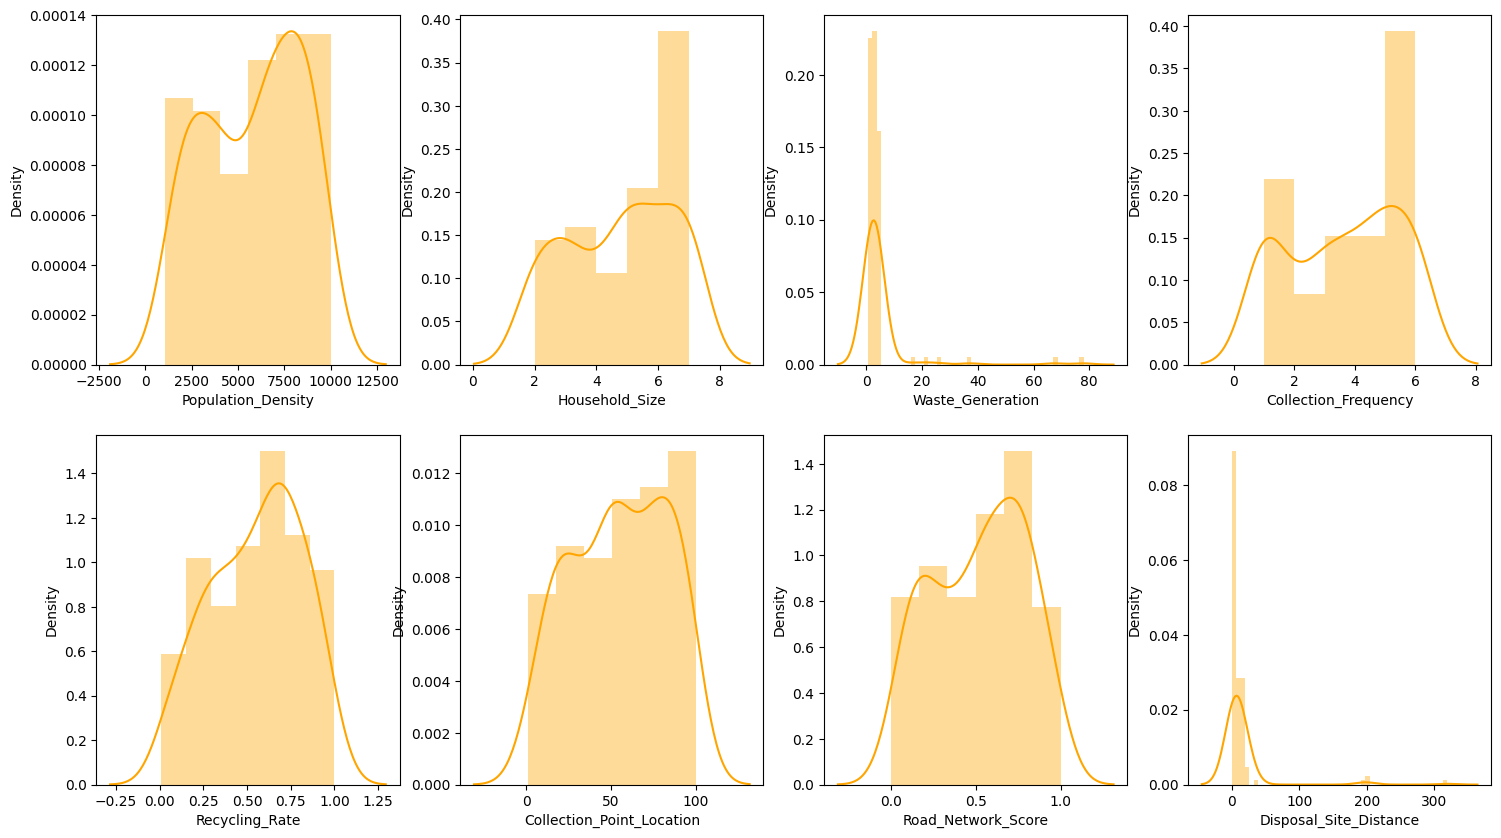

In [12]:
# Graphique de ditribution des variables
plt.figure(figsize=(18, 10))
data2 = data.drop(['Area', 'Top 1 Waste_Type', 'Top 2 Waste_Type', 'Top 3 Waste_Type'], axis=1)
for i, colonne in enumerate(data2, 1):
    plt.subplot(2, 4, i)
    sns.distplot(data2[colonne], color="orange")

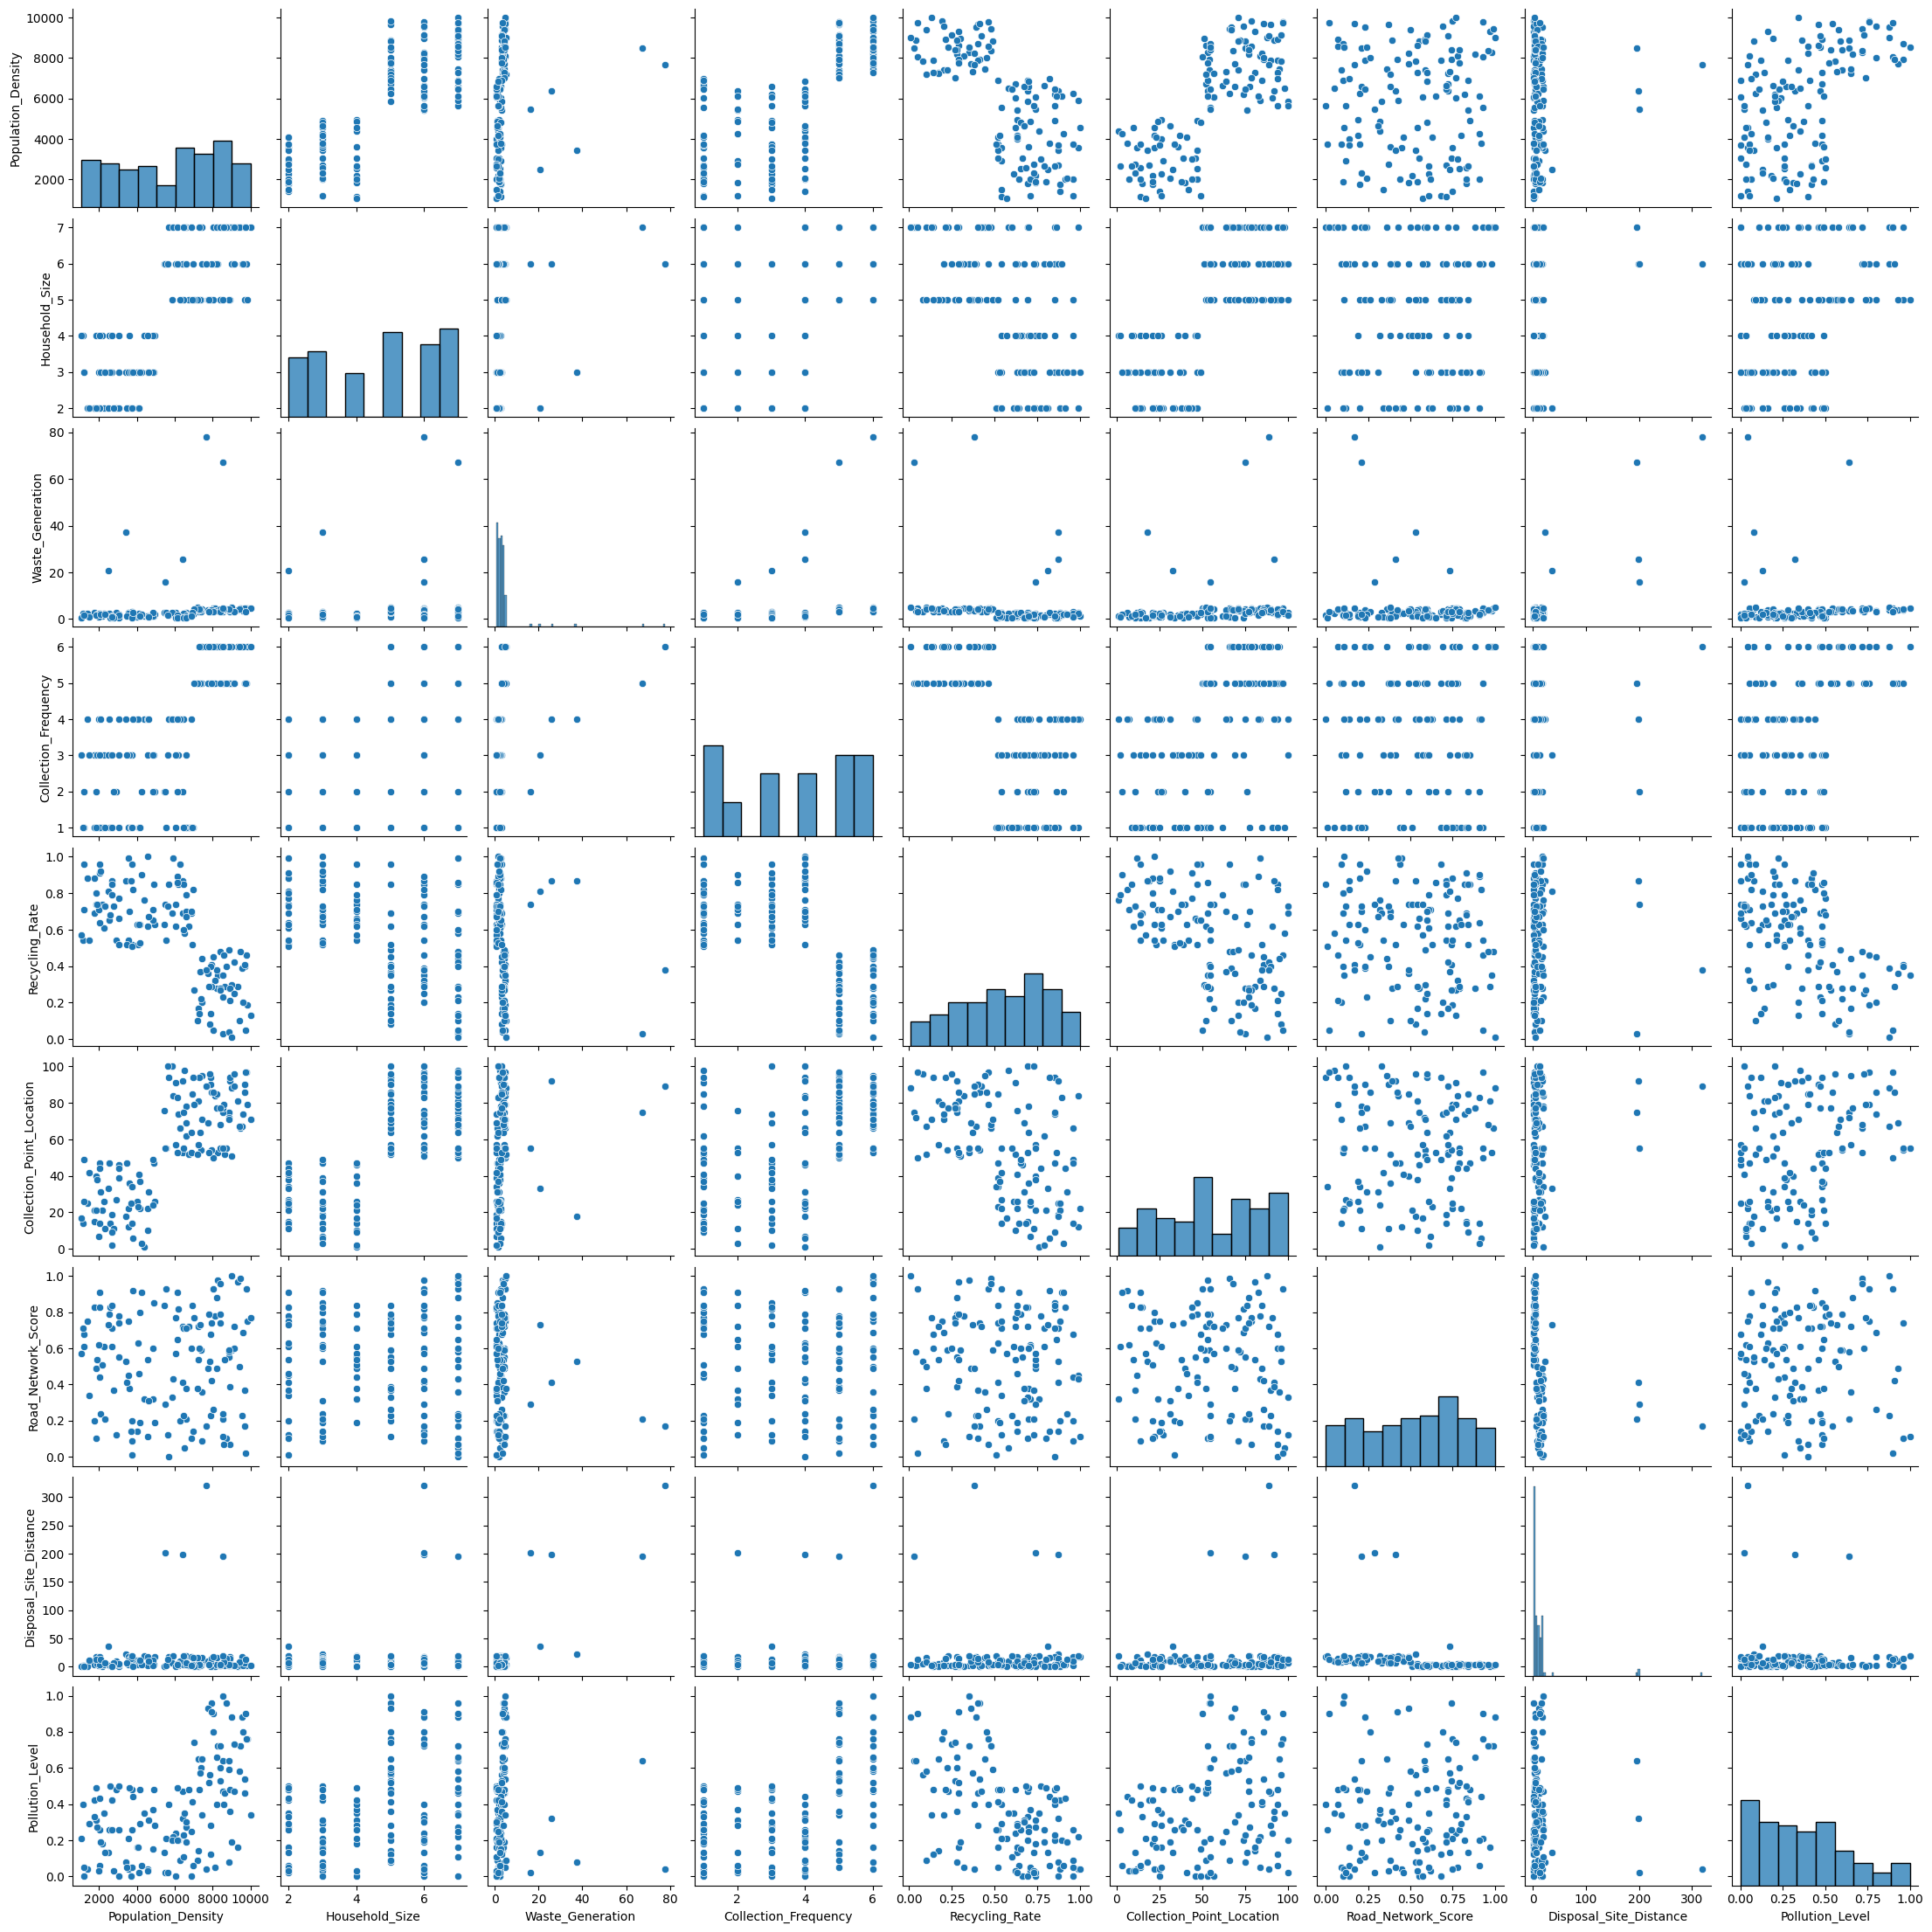

In [ ]:
sns.pairplot(data)

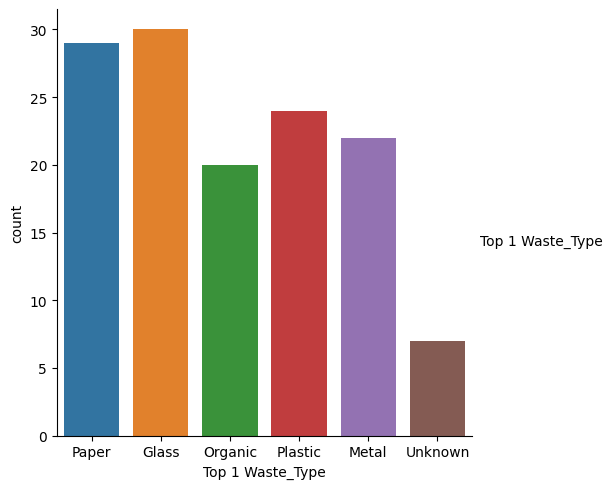

In [ ]:

type_dechets = data[['Top 1 Waste_Type', 'Top 2 Waste_Type', 'Top 3 Waste_Type']]
sns.catplot(data=data , x='Top 1 Waste_Type' , kind='count' , hue='Top 1 Waste_Type')

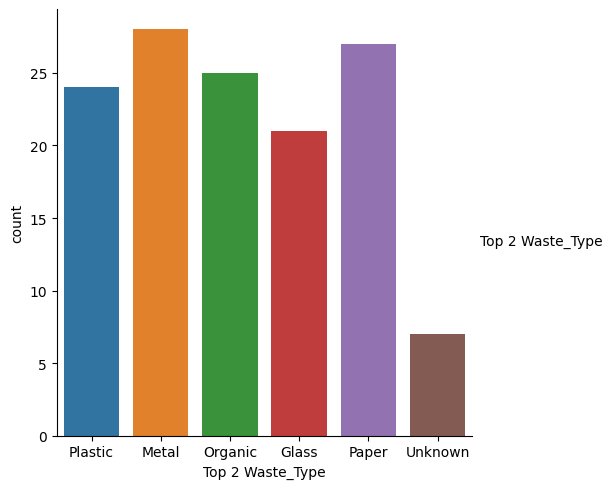

In [ ]:
sns.catplot(data=type_dechets , x='Top 2 Waste_Type' , kind='count' , hue='Top 2 Waste_Type')

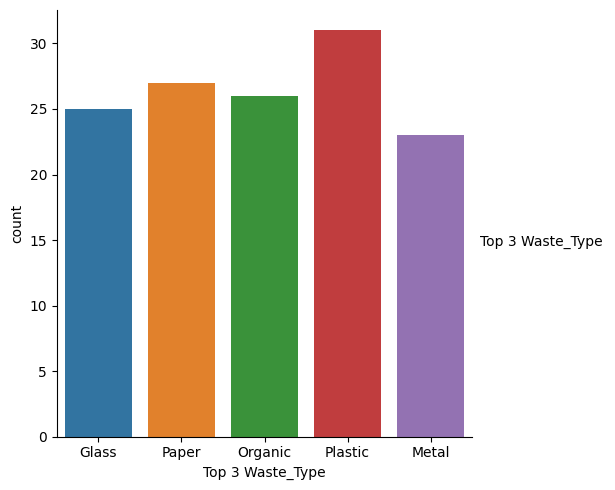

In [ ]:
sns.catplot(data=data , x='Top 3 Waste_Type' , kind='count' , hue='Top 3 Waste_Type')

Facteurs associés aux taux de recyclage:
Nous devons comprendre les divers facteurs qui 
influencent les taux de recyclage dans différentes zones. En identifiant ces facteurs, nous 
visons à mettre en œuvre des stratégies ciblées pour améliorer les taux de recyclage et 
encourager des pratiques plus respectueuses de l'environnement parmi les résidents

In [ ]:
from scipy.stats import pearsonr, spearmanr
# Suppression des colonnes
data1 = data.drop(['Area', 'Top 1 Waste_Type', 'Top 2 Waste_Type', 'Top 3 Waste_Type'], axis=1)
Y1 = data['Recycling_Rate']

# Coefficient de correlation de Pearson
headers = ['variables', 'Coefficient de correlation de Pearson']
data_correlation = []
for col in data1.columns:
    if col != 'Recycling_Rate':
        r_pearson, p_value = pearsonr(data1[col], Y1)
        data_correlation.append([f'{col} et Recycling_Rate:', r_pearson])

print(tabulate(data_correlation, headers=headers))

variables                                       Coefficient de correlation de Pearson
--------------------------------------------  ---------------------------------------
Population_Density et Recycling_Rate:                                      -0.701705
Household_Size et Recycling_Rate:                                          -0.484687
Waste_Generation et Recycling_Rate:                                        -0.153901
Collection_Frequency et Recycling_Rate:                                    -0.647832
Collection_Point_Location et Recycling_Rate:                               -0.497252
Road_Network_Score et Recycling_Rate:                                      -0.0783381
Disposal_Site_Distance et Recycling_Rate:                                  -0.0137111
Pollution_Level et Recycling_Rate:                                         -0.542763


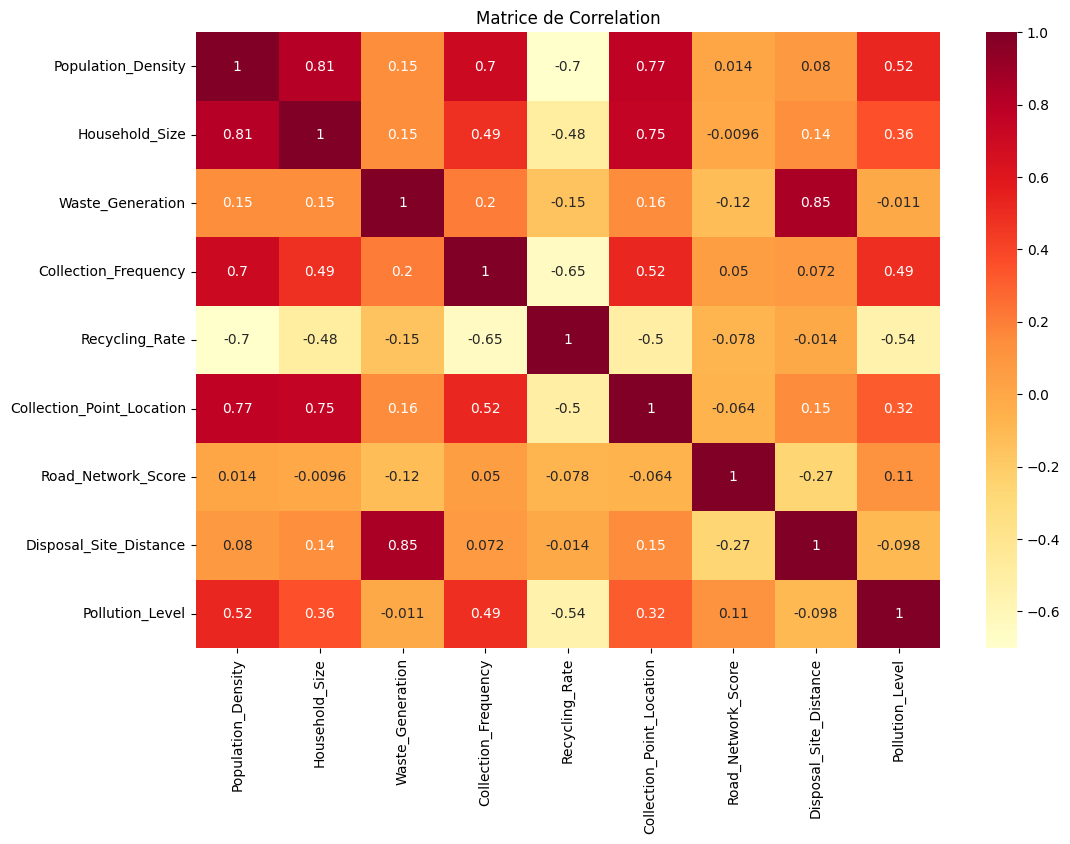

In [ ]:
# Matrice de correlation
plt.figure(figsize=(12,8))
sns.heatmap(data1.corr(), annot=True, cmap='YlOrRd')
plt.title('Matrice de Correlation')
plt.show()

In [ ]:
# Zones ayant un taux de recyclage unferieure a la moyenne
zones_identifiees = data[data['Recycling_Rate'] < data['Recycling_Rate'].mean()]
zones_identifiees

,Area,Population_Density,Household_Size,Waste_Generation,Collection_Frequency,Recycling_Rate,Collection_Point_Location,Road_Network_Score,Disposal_Site_Distance,Pollution_Level,Top 1 Waste_Type,Top 2 Waste_Type,Top 3 Waste_Type
0,Quartier_1,8270.0,6,3.39,6,0.35,53,0.98,2.13,0.72,Paper,Plastic,Glass
5,Quartier_6,7265.0,5,3.35,5,0.17,81,0.54,4.60,0.14,Organic,Glass,Plastic
9,Quartier_10,9322.0,7,3.74,6,0.29,81,0.97,1.32,0.16,Paper,Metal,Organic
12,Quartier_13,7949.0,5,3.86,5,0.41,54,0.74,0.27,0.96,Paper,Organic,Glass
16,Quartier_17,7420.0,6,3.59,5,0.20,71,0.09,8.30,0.34,Paper,Glass,Plastic
...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,Quartier_132,4157.0,3,1.47,1,0.53,37,0.19,11.07,0.48,Glass,Metal,Organic
132,Quartier_133,6915.0,5,2.90,1,0.52,85,0.84,3.88,0.41,Metal,Paper,Plastic
138,Quartier_139,8392.0,5,3.19,5,0.27,77,0.74,3.88,0.53,Glass,Metal,Plastic
140,Quartier_141,7776.0,5,3.14,6,0.29,53,0.79,4.20,0.52,Metal,Organic,Glass


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = data[['Population_Density', 'Collection_Frequency', 'Pollution_Level', 'Collection_Point_Location']]
Y = data['Recycling_Rate']
# Diviser le jeu de donnees
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# Entrainer le modele de regression lineaire
modele = LinearRegression()
modele.fit(X_train, Y_train)
# prediction
y_predict = modele.predict(X_test)
y_predict

array([0.8065209 , 0.50431455, 0.31999509, 0.65525501, 0.80285053,
       0.73453698, 0.36328598, 0.82801648, 0.55729328, 0.6487559 ,
       0.71876739, 0.52404039, 0.32676842, 0.57254508, 0.39437841,
       0.852778  , 0.23617947, 0.67655754, 0.37333999, 0.19563326,
       0.34373436, 0.71129067, 0.47542496, 0.27469282, 0.76173293,
       0.56168551, 0.3543966 ])

In [ ]:
# Evaluation des performances du modele
r2 = r2_score(Y_test, y_predict)
mse = mean_squared_error(Y_test, y_predict)
print(f"coefficient de determination: {r2}")
print(f"somme moyenne des carrees des erreurs: {mse}")

coefficient de determination: 0.5273666445562702
somme moyenne des carrees des erreurs: 0.03492352048150385


Optimisation  des  itinéraires  de  collecte  des  déchets  Nos itinéraires de collecte des 
déchets actuels sont inefficaces, entraînant une consommation de carburant élevée et des 
coûts  opérationnels  accrus.  Nous  devons  optimiser  ces  itinéraires  pour  minimiser  la 
consommation de carburant et réduire le temps passé sur la route. En regroupant les zones 
ayant  des  schémas  de  production  de  déchets  similaires,  nous  pouvons  élaborer  des 
horaires de collecte plus efficaces, ce qui permettra d'économiser des coûts et d'améliorer la 
qualité du service.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import precision_score, confusion_matrix

# selection des variables pertinentes pour notre modele
selector = VarianceThreshold(threshold=0.08)
selector.fit_transform(data1)
selector.get_support()

array([ True,  True,  True,  True, False,  True, False,  True, False])

In [ ]:
features = data1[['Population_Density', 'Household_Size', 'Waste_Generation', 'Collection_Frequency', 'Collection_Point_Location', 'Disposal_Site_Distance']]
# Normaliser les variables
scaler = StandardScaler()
data1_norm = scaler.fit_transform(features)
# Calcul de la variance de chaque variable
data1_norm.var(axis=0)

array([1., 1., 1., 1., 1., 1.])

L'objectif de la méthode du coude est de trouver le nombre optimal de cluster (K) en traçant la variance expliquée par rapport au nombre de clusters et en identifiant le "coude" ou le taux de réduction de la variance commence à se stabiliser. Il aide à déterminer un numéro de cluster approprie pour les K-Means et les algorithmes similaires.

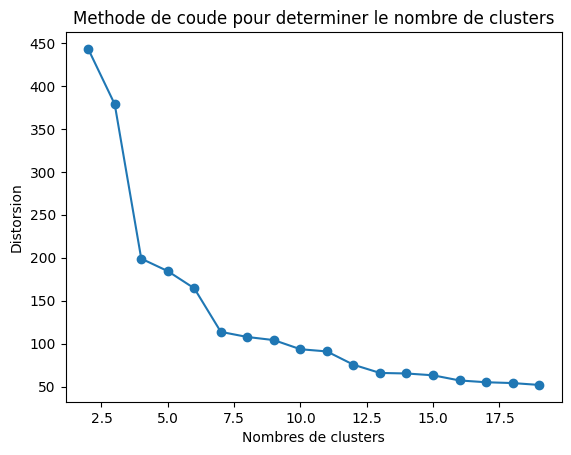

In [ ]:
# Determinons le nombre optimum de clusters avec la methode de coude
silhouettes = []
inertie = []
for i in range(2, 20):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(data1_norm)
    inertie.append(km.inertia_)
    silhouettes.append(silhouette_score(data1_norm, km.labels_))
plt.plot(range(2, 20), inertie, marker='o')
plt.xlabel("Nombres de clusters")
plt.ylabel("Distorsion")
plt.title("Methode de coude pour determiner le nombre de clusters")
plt.show()

Le score de silhouette est calculé pour chaque point de données en mesurant la similarité avec son propre cluster par rapport aux clusters voisins les plus proches. Il varie de -1 (mauvaise adéquation) a +1 (bonne adéquation), un score élevé indique des clusters bien définis. Cela permet de déterminer le nombre optimal de clusters dans un ensemble de données.

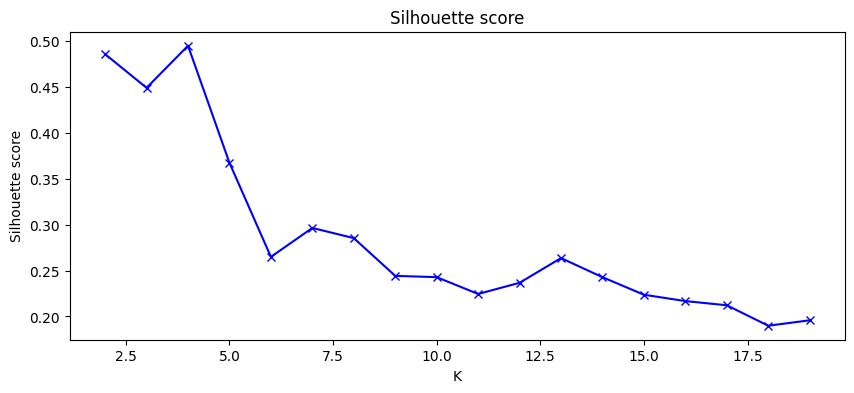

In [ ]:
# Graphique du score silhouette score
plt.figure(figsize=(10, 4))
plt.plot(range(2, 20), silhouettes, 'bx-')
plt.xlabel('K')
plt.ylabel("Silhouette score")
plt.title("Silhouette score")
plt.show()

In [ ]:
# Creeons notre modele avec k=4
optimal_cluster = 4
model = KMeans(n_clusters=optimal_cluster)
labels = model.fit_predict(data1_norm)
data['cluster'] = labels
data

,Area,Population_Density,Household_Size,Waste_Generation,Collection_Frequency,Recycling_Rate,Collection_Point_Location,Road_Network_Score,Disposal_Site_Distance,Pollution_Level,Top 1 Waste_Type,Top 2 Waste_Type,Top 3 Waste_Type,cluster
0,Quartier_1,8270.0,6,3.39,6,0.35,53,0.98,2.13,0.72,Paper,Plastic,Glass,0
1,Quartier_2,1860.0,4,2.31,2,0.74,40,0.49,17.95,0.31,Paper,Metal,Glass,1
2,Quartier_3,6390.0,5,1.20,2,0.69,53,0.72,4.62,0.47,Glass,Organic,Paper,3
3,Quartier_4,6191.0,6,0.56,3,0.85,74,0.82,2.38,0.20,Glass,Metal,Organic,3
4,Quartier_5,6734.0,5,2.11,1,0.62,52,0.72,2.46,0.48,Organic,Plastic,Glass,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,Quartier_139,8392.0,5,3.19,5,0.27,77,0.74,3.88,0.53,Glass,Metal,Plastic,0
139,Quartier_140,2306.0,3,2.21,1,0.73,11,0.21,6.02,0.13,Paper,Metal,Organic,1
140,Quartier_141,7776.0,5,3.14,6,0.29,53,0.79,4.20,0.52,Metal,Organic,Glass,0
141,Quartier_142,6864.0,7,1.30,4,0.70,64,0.60,2.24,0.25,Plastic,Organic,Paper,3


In [ ]:

for cluster in range(optimal_cluster):
    print(f"Cluster {cluster}:")
    print(data[data['cluster'] == cluster].drop(['Area', 'Top 1 Waste_Type', 'Top 2 Waste_Type', 'Top 3 Waste_Type'], axis=1).describe())
    

Cluster 0:
       Population_Density  Household_Size  Waste_Generation  \
count           50.000000       50.000000         50.000000   
mean          8485.820000        5.960000          3.938000   
std            830.420564        0.902604          0.561452   
min           7019.000000        5.000000          3.060000   
25%           7882.250000        5.000000          3.400000   
50%           8467.000000        6.000000          4.050000   
75%           9084.000000        7.000000          4.295000   
max           9996.000000        7.000000          4.930000   

       Collection_Frequency  Recycling_Rate  Collection_Point_Location  \
count             50.000000       50.000000                   50.00000   
mean               5.500000        0.280400                   74.90000   
std                0.505076        0.131614                   15.13106   
min                5.000000        0.010000                   50.00000   
25%                5.000000        0.192500        

In [ ]:

for cluster in range(optimal_cluster):
    zones_cluster = data[data['cluster'] == cluster]['Area'].tolist()
    print(f"Zones appartenent au cluster {cluster}: {', '.join(zones_cluster)}")

Zones appartenent au cluster 0: Quartier_1, Quartier_6, Quartier_10, Quartier_13, Quartier_17, Quartier_21, Quartier_22, Quartier_24, Quartier_37, Quartier_39, Quartier_40, Quartier_43, Quartier_44, Quartier_46, Quartier_52, Quartier_56, Quartier_57, Quartier_62, Quartier_64, Quartier_65, Quartier_66, Quartier_67, Quartier_68, Quartier_69, Quartier_73, Quartier_74, Quartier_75, Quartier_76, Quartier_80, Quartier_87, Quartier_91, Quartier_93, Quartier_94, Quartier_96, Quartier_98, Quartier_100, Quartier_102, Quartier_105, Quartier_107, Quartier_108, Quartier_113, Quartier_114, Quartier_116, Quartier_119, Quartier_120, Quartier_122, Quartier_124, Quartier_139, Quartier_141, Quartier_143
Zones appartenent au cluster 1: Quartier_2, Quartier_11, Quartier_12, Quartier_14, Quartier_18, Quartier_20, Quartier_23, Quartier_25, Quartier_26, Quartier_27, Quartier_28, Quartier_29, Quartier_31, Quartier_33, Quartier_34, Quartier_35, Quartier_36, Quartier_42, Quartier_47, Quartier_49, Quartier_50, Qu

In [ ]:
zone_type_dechets = data.groupby('Area').agg({
    'Top 1 Waste_Type': 'sum',
    'Top 2 Waste_Type': 'sum',
    'Top 3 Waste_Type': 'sum'
})
zone_type_dechets

,Top 1 Waste_Type,Top 2 Waste_Type,Top 3 Waste_Type
Area,,,
Quartier_1,Paper,Plastic,Glass
Quartier_10,Paper,Metal,Organic
Quartier_100,Metal,Organic,Plastic
Quartier_101,Metal,Plastic,Glass
Quartier_102,Metal,Paper,Organic
...,...,...,...
Quartier_94,Organic,Paper,Metal
Quartier_96,Metal,Organic,Plastic
Quartier_97,Metal,Paper,Glass


In [ ]:
s1 = silhouette_score(data1_norm, labels)
model.inertia_

198.85681655799897

In [ ]:
from sklearn.cluster import AgglomerativeClustering

cah = AgglomerativeClustering(n_clusters=3)
labels_predict = cah.fit_predict(data1_norm)
labels_predict

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 2, 0, 0, 2, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 2, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0],
      dtype=int64)

In [ ]:
s = silhouette_score(data1_norm, labels_predict)
s

0.530894283089984